# Spatial component — residual autocorrelation (LISA) and success-rate curve (Chapter 6)

Builds two Results figures of the spatial component (ZINB + BYM2, model **M1**) and the numbers
that go with them:

- **`fig_lisa_residuales`** — local indicators of spatial association (LISA) of the Pearson
  residuals. If the residuals of M0 are available (`salidas/residuales_pearson_M0.csv`), the
  figure is the before/after pair: **(a)** M0, without spatial field; **(b)** M1, with the BYM2
  field. Without that file, only M1 is drawn.
- **`fig_curva_exito_clases`** — success-rate curve with the four susceptibility classes
  (50 / 80 / 95 % of the inventory), in the same colours as map (c).
- **Tables** — global Moran's *I* (observed density, residuals of M0 and M1), LISA counts and
  the class cuts on the curve.

Same design rules as `results_spatial_cap6.ipynb`: no panel titles, letters in the upper-left
corner, legend inside the panel, frame on four sides, lat/lon only on the left and bottom axes,
slope units without outline and the AMVA boundary as the only line.

**Inputs** (paths relative to the folder of `SUSCEPTIBILIDAD_v2.qmd`):

| File | Written by | Used for |
|---|---|---|
| `salidas/su_resultados_ZINB_BYM2.gpkg` | chunk `exportar` | M1 residuals, λ, classes |
| `salidas/residuales_pearson_M0.csv` | R snippet below (optional) | panel (a) of the LISA figure |
| `amva.geojson` | — | boundary line |

**R snippet to export the M0 residuals** (paste in the qmd after the chunk `moran`):

```r
mu0 <- a_conteo(fits$M0, su$area_km2, N)
k0  <- get_hyper(fits$M0, "^size for")
p0  <- get_hyper(fits$M0, "zero-probability"); if (is.na(p0)) p0 <- 0
write.csv(data.frame(su_id = su$su_id,
                     r_pearson_M0 = resid_pearson(su$mm, mu0, k0, p0)),
          file.path(DIR_OUT, "residuales_pearson_M0.csv"), row.names = FALSE)
```

**Decisiones del test (las mismas que describe Métodos):**

- Mismo grafo de contigüidad reina del modelo, estandarizado por filas. La celda 3 verifica que
  coincide con el de R (5,8 vecinas en promedio, 31 islas, 63 componentes).
- Permutaciones condicionales con semilla fija (2026), así que el resultado es reproducible:
  999 para el Morán global (una sola prueba) y **9.999 para el LISA** (una prueba por unidad).
- `esda` entrega un p "dirigido": la cola del lado donde cae el valor observado. Bajo la hipótesis
  nula ese p se reparte entre 0 y 0,5, así que **se duplica** para obtener un p a dos colas.
- Corrección de Benjamini–Hochberg sobre las unidades con vecinas; las islas no se prueban y
  quedan como *Not significant*.
- **Por qué 9.999 y no 999.** Con 999 permutaciones el p mínimo (a dos colas) es 0,002, y con
  FDR al 5 % sobre ~60.900 pruebas ninguna unidad pasa a menos que ~2.440 unidades lleguen a ese
  mínimo. En la práctica el mapa sale vacío aunque haya estructura: por eso el LISA del qmd salió
  todo gris. Con 9.999 el mínimo es 0,0002 y bastan ~245. (Probado: con 9.999 el resultado cambia
  menos de 2 % entre semillas y menos de 10 % frente a 49.999.)
- Se reporta también el conteo con p < 0,05 **sin** corregir, frente al 5 % esperado por azar.
- Morán global: una cola (autocorrelación positiva), igual que `moran.mc` en R.

> Si reajustas M1 sin los registros posteriores al 31-mar-2025 (`M1_train`), vuelve a exportar
> los dos archivos y a correr este notebook: todas las cifras salen de aquí.

## 1. Libraries and settings

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter
from shapely.geometry import Polygon, MultiPolygon
from statsmodels.stats.multitest import multipletests
try:
    from libpysal.weights import Queen
    import esda
except ImportError as e:
    raise ImportError('Faltan libpysal/esda: pip install esda libpysal numba') from e

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)   # aviso de esda sobre 'alternative'

try:
    import numba  # noqa: F401  (esda la usa para las permutaciones)
except ImportError:
    print('AVISO - sin numba el LISA tarda mucho más: pip install numba')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'legend.fontsize': 8,
    'legend.title_fontsize': 8.5,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
})

# ---------------------------------------------------------------- settings
PATH_RES    = 'salidas/su_resultados_ZINB_BYM2.gpkg'
PATH_M0     = 'salidas/residuales_pearson_M0.csv'     # opcional
PATH_AMVA   = '/home/oisanchezp/Thesis/data/metadata/amva.geojson'
OUT_DIR     = Path('00Figuras/06Seccion')
OUT_TAB     = Path('salidas')
OUT_LISA    = 'fig_lisa_residuales'
OUT_SUCCESS = 'fig_curva_exito_clases'

NSIM_GLOBAL = 999   # Morán global: una sola prueba, 999 permutaciones bastan
NSIM_LISA   = 9999  # LISA: 60 mil pruebas con FDR; con 999 ninguna unidad puede pasar (ver arriba)
SEED   = 2026
ALPHA  = 0.05
N_JOBS = 1          # esda en paralelo (-1) puede fallar en Windows; con numba, 1 basta
TARGETS = (0.50, 0.80, 0.95)

CRS_PLOT   = 'EPSG:4326'
SIMPLIFY_M = 5
AMVA_LW    = 0.8
INK   = '#1a1a19'
MUTED = '#6b6b6b'

# LISA: esquema divergente. Rojo = residual por encima de la media, azul = por debajo;
# oscuro = agrupamiento (vecinas iguales), claro = atípico (vecinas opuestas); gris = no
# significativo. Validado: todo par separado por un Delta E >= 20 (visión normal) y >= 15
# (protan/deutan). En los colores del qmd, Low-High y el gris quedaban a 5,9: casi iguales.
LISA_CATS = ['High-High', 'Low-Low', 'High-Low', 'Low-High', 'Not significant']
LISA_COLS = {'High-High': '#c62828', 'High-Low': '#f28e86',
             'Low-Low':   '#1c5cab', 'Low-High': '#86b6ef',
             'Not significant': '#ececec'}
LISA_TXT  = {'High-High': 'High–High', 'Low-Low': 'Low–Low', 'High-Low': 'High–Low',
             'Low-High': 'Low–High', 'Not significant': 'Not significant'}
QUAD = {1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}   # códigos de esda

# Clases: la misma paleta del mapa (c), en el orden en que aparecen a lo largo de la curva
SUSC_FROM_ES = {'Muy alta': 'Very high', 'Alta': 'High', 'Media': 'Moderate', 'Baja': 'Low'}
SUSC_CATS  = ['Very high', 'High', 'Moderate', 'Low']
SUSC_COLS  = {'Very high': '#ff0000', 'High': '#ffbe00', 'Moderate': '#12ff55', 'Low': '#0044ff'}
BAND_ALPHA = 0.22

OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)
print('esda', esda.__version__, '| geopandas', gpd.__version__)

esda 2.10.0 | geopandas 1.1.4


## 2. Load the model results

`r_pearson` is the Pearson residual of M1 under the ZINB, written by the qmd. If
`residuales_pearson_M0.csv` exists, the M0 residuals are joined by `su_id`.

In [2]:
res = gpd.read_file(PATH_RES)
REQUIRED = ['su_id', 'area_km2', 'mm', 'lambda', 'clase_susc', 'r_pearson']
missing = [c for c in REQUIRED if c not in res.columns]
if missing:
    raise KeyError(f'Faltan columnas en {PATH_RES}: {missing}')
if res[REQUIRED].isna().any().any():
    raise ValueError('Hay NaN en las columnas del modelo:\n' + res[REQUIRED].isna().sum().to_string())
if res.crs is None or res.crs.is_geographic:
    raise ValueError('Se espera un CRS proyectado (metros).')
res = res.reset_index(drop=True)

HAS_M0 = Path(PATH_M0).exists()
if HAS_M0:
    m0 = pd.read_csv(PATH_M0)
    if not {'su_id', 'r_pearson_M0'} <= set(m0.columns):
        raise KeyError(f'{PATH_M0} debe tener las columnas su_id y r_pearson_M0')
    res = res.merge(m0[['su_id', 'r_pearson_M0']], on='su_id', how='left', validate='one_to_one')
    if res['r_pearson_M0'].isna().any():
        raise ValueError(f'{int(res["r_pearson_M0"].isna().sum())} unidades sin residual de M0: '
                         'revisa que el CSV salga del mismo modelo y del mismo su_id.')
    print('M0 residuals joined: the LISA figure will have two panels.')
else:
    print(f'AVISO - no encuentro {PATH_M0}: la figura LISA tendrá solo el panel de M1.')

N = len(res)
print(f'Slope units: {N:,} | landslides: {int(res["mm"].sum()):,} | CRS: {res.crs}')
print('\nPearson residuals of M1:')
print(res['r_pearson'].describe(percentiles=[.01, .5, .99]).round(3).to_string())

M0 residuals joined: the LISA figure will have two panels.
Slope units: 60,914 | landslides: 6,198 | CRS: EPSG:32618

Pearson residuals of M1:
count    60914.000
mean        -0.113
std          0.563
min         -1.125
1%          -0.704
50%         -0.160
99%          2.311
max         32.490


## 3. Neighbourhood graph

Queen contiguity, as in the model. The check below compares it with the graph of the qmd; a
difference would mean that the diagnostic is not using the neighbours the model used.

In [3]:
w = Queen.from_dataframe(res, use_index=False, silence_warnings=True)
print(f'Mean neighbours : {w.mean_neighbors:.2f}   (R: 5.8)')
print(f'Islands         : {len(w.islands)}      (R: 31)')
print(f'Components      : {w.n_components}      (R: 63)')
if len(w.islands) != 31 or w.n_components != 63:
    print('AVISO - el grafo no coincide con el del modelo: revisa la geometría o la tolerancia.')
w.transform = 'r'
ISLAND = np.zeros(N, dtype=bool)
ISLAND[w.islands] = True

Mean neighbours : 5.82   (R: 5.8)
Islands         : 31      (R: 31)
Components      : 63      (R: 63)


## 4. Global Moran's I

One-sided test (positive autocorrelation), as `moran.mc` in R. The same sequence as in
Methods: observed density, residuals of M0 (no spatial field) and residuals of M1.

In [4]:
def moran_global(x, label, nsim=NSIM_GLOBAL, seed=SEED):
    """Global Moran's I with a one-sided permutation p-value (I larger than expected)."""
    x = np.asarray(x, dtype=float)
    np.random.seed(seed)                       # esda.Moran no recibe semilla
    m = esda.Moran(x, w, permutations=nsim)
    p_greater = ((m.sim >= m.I).sum() + 1) / (nsim + 1)
    return {'series': label, 'I': m.I, 'expected': m.EI, 'p_value': p_greater}


series = [('Observed density', res['mm'] / res['area_km2'])]
if HAS_M0:
    series.append(('Residuals of M0 (no spatial field)', res['r_pearson_M0']))
series.append(('Residuals of M1 (BYM2 field)', res['r_pearson']))

tab_moran = pd.DataFrame([moran_global(v, k) for k, v in series])
tab_moran.to_csv(OUT_TAB / 'tabla_res_moran.csv', index=False)
print(tab_moran.round(4).to_string(index=False))
I_BY = {('M0' if 'M0' in s else 'M1' if 'M1' in s else 'obs'): i
        for s, i in zip(tab_moran['series'], tab_moran['I'])}

                            series      I  expected  p_value
                  Observed density 0.1463      -0.0    0.001
Residuals of M0 (no spatial field) 0.1534      -0.0    0.001
      Residuals of M1 (BYM2 field) 0.0060      -0.0    0.013


## 5. LISA

`esda` returns the quadrant of each unit and a directed pseudo *p*; the *p* is doubled to make
it two-sided, the islands are left out, and the false discovery rate is controlled with
Benjamini–Hochberg. The printout gives the numbers the text needs.

In [5]:
def lisa_classes(x, label, nsim=NSIM_LISA, seed=SEED, alpha=ALPHA):
    """LISA classes of one variable, two-sided permutation p-values and BH-FDR.

    Returns a Series with one class per slope unit and a dict with the counts for the text.
    """
    x = np.asarray(x, dtype=float)
    lm = esda.Moran_Local(x, w, transformation='r', permutations=nsim, seed=seed,
                          keep_simulations=False, n_jobs=N_JOBS)
    p2 = np.minimum(1.0, 2.0 * lm.p_sim.astype(float))   # dirigido -> dos colas
    p2[ISLAND] = np.nan
    tested = ~np.isnan(p2)

    signif = np.zeros(N, dtype=bool)
    signif[tested] = multipletests(p2[tested], alpha=alpha, method='fdr_bh')[0]

    quad = pd.Series(lm.q).map(QUAD).to_numpy()
    cls = pd.Series(np.where(signif, quad, 'Not significant'), index=res.index)

    n_test = int(tested.sum())
    p_min = 2.0 / (nsim + 1)
    at_min = int((p2[tested] <= p_min * (1 + 1e-6)).sum())   # p viene en float32
    stats = {
        'series': label,
        'tested_units': n_test,
        'p<0.05_uncorrected': int((p2[tested] < alpha).sum()),
        'expected_by_chance': int(round(alpha * n_test)),
        'significant_FDR': int(signif.sum()),
        'min_p_two_sided': p_min,
        'units_at_min_p': at_min,
        'units_at_min_p_needed': int(np.ceil(p_min * n_test / alpha)),
    }
    for c in LISA_CATS:
        stats[c] = int((cls == c).sum())
    return cls, stats


lisa, lisa_stats = {}, []
for key, col, label in [('M0', 'r_pearson_M0', 'Residuals of M0'), ('M1', 'r_pearson', 'Residuals of M1')]:
    if key == 'M0' and not HAS_M0:
        continue
    lisa[key], s = lisa_classes(res[col], label)
    lisa_stats.append(s)
    print(f"--- {label}")
    print(f"  p < 0.05 before correction : {s['p<0.05_uncorrected']:,}"
          f"  (by chance: {s['expected_by_chance']:,}; ratio {s['p<0.05_uncorrected']/s['expected_by_chance']:.2f})")
    print(f"  significant after FDR      : {s['significant_FDR']:,}")
    print(f"  units at the minimum p     : {s['units_at_min_p']:,} "
          f"(FDR needs at least {s['units_at_min_p_needed']:,} before any unit can pass)")

tab_lisa = pd.DataFrame(lisa_stats)
tab_lisa.to_csv(OUT_TAB / 'tabla_res_lisa.csv', index=False)
print()
print(tab_lisa.set_index('series')[LISA_CATS].T.to_string())

# Dónde caen las unidades significativas (zonas de lluvia; verifica los nombres)
ZONE_NAMES = {'1': 'Oriente', '2': 'Norte', '3': 'Sur', '4': 'SAP', '5': 'Occidente'}
if 'zona' in res.columns:
    zona = res['zona'].astype(str).map(ZONE_NAMES).fillna(res['zona'].astype(str))
    by_zone = pd.DataFrame({k: zona[v != 'Not significant'].value_counts() for k, v in lisa.items()})
    by_zone = by_zone.fillna(0).astype(int)
    by_zone['units_in_zone'] = zona.value_counts()
    print('\nSignificant units by rainfall zone:')
    print(by_zone.sort_values(by_zone.columns[-2], ascending=False).to_string())

--- Residuals of M0
  p < 0.05 before correction : 9,258  (by chance: 3,044; ratio 3.04)
  significant after FDR      : 1,980
  units at the minimum p     : 734 (FDR needs at least 244 before any unit can pass)
--- Residuals of M1
  p < 0.05 before correction : 6,120  (by chance: 3,044; ratio 2.01)
  significant after FDR      : 599
  units at the minimum p     : 436 (FDR needs at least 244 before any unit can pass)

series           Residuals of M0  Residuals of M1
High-High                     81               16
Low-Low                     1736              411
High-Low                      71              168
Low-High                      92                4
Not significant            58934            60315

Significant units by rainfall zone:
            M0   M1  units_in_zone
zona                              
Occidente  931  199           8490
Sur        442  182          14374
Norte      129  109          29676
SAP        471   93           2606
Oriente      7   16           57

## 6. Figure — LISA maps

The legend always lists the five classes with their number of units, so an empty class reads
as "0" and not as a missing colour. The model and its global Moran's *I* go in the legend
title.

Saved: 00Figuras/06Seccion/fig_lisa_residuales.png


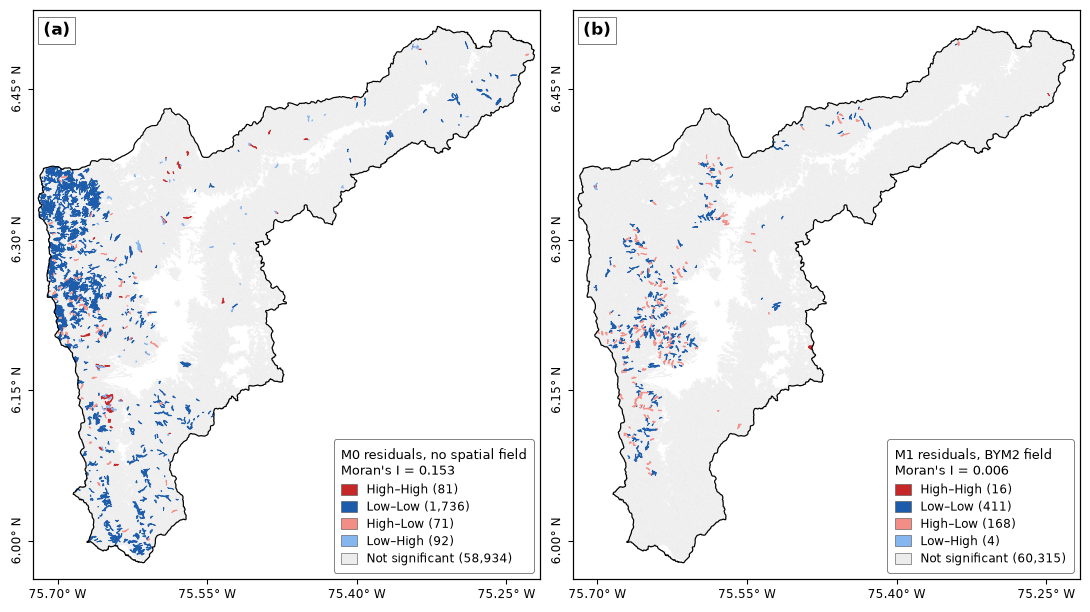

In [7]:
def outer_outline(gdf):
    # Contorno exterior de las slope units (solo si falta amva.geojson)
    merged = gdf.geometry.buffer(1).union_all().buffer(-1)
    parts = merged.geoms if isinstance(merged, MultiPolygon) else [merged]
    return gpd.GeoSeries([MultiPolygon([Polygon(p.exterior) for p in parts if p.area > 1e6])],
                         crs=gdf.crs)


if Path(PATH_AMVA).exists():
    amva = gpd.read_file(PATH_AMVA).to_crs(res.crs).dissolve().geometry
else:
    print(f'AVISO - no encuentro {PATH_AMVA}: dibujo el contorno de las slope units')
    amva = outer_outline(res)
amva = amva.to_crs(CRS_PLOT)

su_plot = res[['geometry']].copy()
if SIMPLIFY_M:
    su_plot['geometry'] = su_plot.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
su_plot = su_plot.to_crs(CRS_PLOT)

b = su_plot.total_bounds
a = amva.total_bounds
XMIN, YMIN = min(b[0], a[0]), min(b[1], a[1])
XMAX, YMAX = max(b[2], a[2]), max(b[3], a[3])
PADX, PADY = (XMAX - XMIN) * 0.01, (YMAX - YMIN) * 0.03


def fmt_lon(x, _):
    return f'{abs(x):.2f}° {"W" if x < 0 else "E"}'


def fmt_lat(y, _):
    return f'{abs(y):.2f}° {"S" if y < 0 else "N"}'


def lisa_panel(ax, cls, letter, legend_title):
    """One LISA map: grey first, significant classes on top, legend with counts."""
    for c in ['Not significant'] + LISA_CATS[:-1]:
        sub = su_plot[cls.to_numpy() == c]
        if len(sub):
            # las unidades significativas llevan un borde de su mismo color: una slope unit
            # mide ~0,016 km2 y sin borde casi no se ve a la escala del valle
            edge = 'none' if c == 'Not significant' else LISA_COLS[c]
            sub.plot(ax=ax, color=LISA_COLS[c], edgecolor=edge, linewidth=0.5,
                     zorder=2 if c == 'Not significant' else 3, rasterized=True)
    amva.boundary.plot(ax=ax, color='black', linewidth=AMVA_LW, zorder=5)

    handles = [Patch(facecolor=LISA_COLS[c], edgecolor='0.35', linewidth=0.4,
                     label=f'{LISA_TXT[c]} ({int((cls == c).sum()):,})') for c in LISA_CATS]
    leg = ax.legend(handles=handles, title=legend_title, loc='lower right', frameon=True,
                    framealpha=0.95, edgecolor='0.45', borderpad=0.6, handlelength=1.3,
                    handleheight=1.0, labelspacing=0.35)
    leg.get_frame().set_linewidth(0.6)
    leg._legend_box.align = 'left'

    ax.set_xlim(XMIN - PADX, XMAX + PADX)
    ax.set_ylim(YMIN - PADY, YMAX + PADY)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(0.8); sp.set_color('black')
    ax.tick_params(direction='out', length=3, width=0.7, top=False, right=False,
                   labelsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(5, prune='both'))
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
    ax.tick_params(axis='y', rotation=90)
    for t in ax.get_yticklabels():
        t.set_va('center')
    if letter:
        ax.text(0.02, 0.98, letter, transform=ax.transAxes, ha='left', va='top', fontsize=11,
                fontweight='bold', zorder=10,
                bbox=dict(boxstyle='square,pad=0.30', facecolor='white', edgecolor='0.45',
                          linewidth=0.6))


panels = []
if HAS_M0:
    panels.append(('M0', f"M0 residuals, no spatial field\nMoran's I = {I_BY['M0']:.3f}"))
panels.append(('M1', f"M1 residuals, BYM2 field\nMoran's I = {I_BY['M1']:.3f}"))

fig, axes = plt.subplots(1, len(panels), figsize=(4.9 * len(panels), 6.0),
                         constrained_layout=True, squeeze=False)
for k, (ax, (key, title)) in enumerate(zip(axes[0], panels)):
    letter = f'({"ab"[k]})' if len(panels) > 1 else ''
    lisa_panel(ax, lisa[key], letter, title)

fig.savefig(OUT_DIR / f'{OUT_LISA}.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / f'{OUT_LISA}.pdf', dpi=300, bbox_inches='tight')
print('Saved:', OUT_DIR / f'{OUT_LISA}.png')
plt.show()

## 7. Figure — success-rate curve

Slope units are ordered by decreasing expected density $\lambda_i$; the curve accumulates the
area (x) and the recorded landslides (y) along that order. The class bands come from
`clase_susc` (the classes of the qmd), so they are exactly the ones of map (c); the cell checks
that each band starts where the curve reaches 50, 80 and 95 %. Set `ZOOM = 0.40` to add a
second panel with the first 40 % of the area.

AUC of the success-rate curve: 0.913
 target  area_%  landslides_%  units  class_edge_area_%
   0.50     3.6          50.0   2322                3.6
   0.80    13.3          80.0   8441               13.3
   0.95    35.9          95.0  22675               35.9
    1% of the area holds 25.3 % of the landslides
    5% of the area holds 57.6 % of the landslides
   10% of the area holds 74.0 % of the landslides
   20% of the area holds 87.3 % of the landslides
Saved: 00Figuras/06Seccion/fig_curva_exito_clases.png


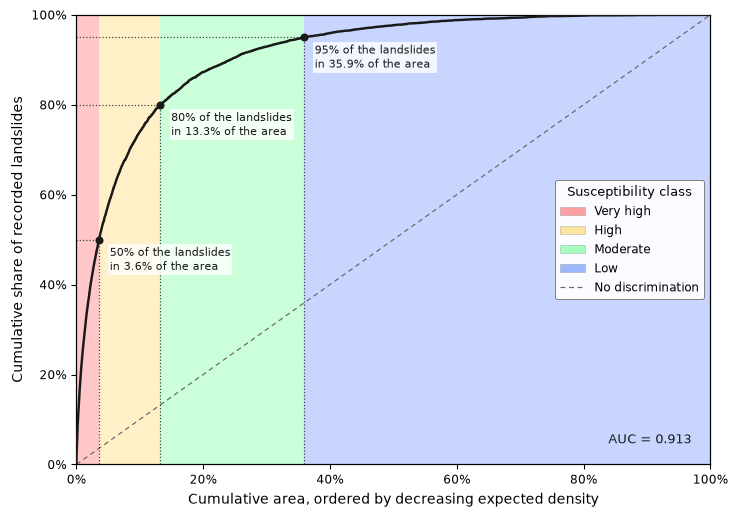

In [8]:
ZOOM = None          # p. ej. 0.40 para añadir un panel ampliado

o = res.sort_values('lambda', ascending=False, kind='mergesort')
x_area = o['area_km2'].cumsum().to_numpy() / o['area_km2'].sum()
y_ls   = o['mm'].cumsum().to_numpy() / o['mm'].sum()
trapz = getattr(np, 'trapezoid', None) or np.trapz        # numpy < 2.0 solo tiene trapz
auc = float(trapz(np.r_[0.0, y_ls], np.r_[0.0, x_area]))

# Bordes de las bandas a partir de las clases del qmd
cls_sorted = o['clase_susc'].map(SUSC_FROM_ES).to_numpy()
if pd.isna(cls_sorted).any():
    raise ValueError('Hay clases de susceptibilidad sin traducir.')
change = np.flatnonzero(cls_sorted[1:] != cls_sorted[:-1]) + 1
seq = [cls_sorted[0]] + [cls_sorted[i] for i in change]
if seq != SUSC_CATS:
    raise ValueError(f'Las clases no son monótonas a lo largo de lambda: {seq}')
edges = np.r_[0.0, x_area[change - 1], 1.0]

# Donde la curva alcanza 50, 80 y 95 %: primera unidad con y >= objetivo. En R, cut(right =
# TRUE) deja esa unidad en la clase de abajo, asi que banda y cruce difieren a lo sumo en una.
cuts = []
for t, i in zip(TARGETS, change):
    k = int(np.searchsorted(y_ls, t, side='left'))
    if abs(i - k) > 1:
        print(f'AVISO - el corte del {t:.0%} no coincide con clase_susc ({i} vs {k})')
    cuts.append({'target': t, 'area_share': x_area[k], 'landslide_share': y_ls[k],
                 'units_above': k + 1, 'class_edge_area': x_area[i - 1]})
tab_cuts = pd.DataFrame(cuts)
tab_cuts.to_csv(OUT_TAB / 'tabla_res_exito_cortes.csv', index=False)

print(f'AUC of the success-rate curve: {auc:.3f}')
print(tab_cuts.assign(area_share=lambda d: (100 * d.area_share).round(1),
                      landslide_share=lambda d: (100 * d.landslide_share).round(1),
                      class_edge_area=lambda d: (100 * d.class_edge_area).round(1))
      .rename(columns={'area_share': 'area_%', 'landslide_share': 'landslides_%',
                       'units_above': 'units', 'class_edge_area': 'class_edge_area_%'})
      .to_string(index=False))
for a_ in (0.01, 0.05, 0.10, 0.20):
    print(f'  {a_:>4.0%} of the area holds {100 * y_ls[np.searchsorted(x_area, a_)]:.1f} % of the landslides')


def success_panel(ax, xmax=1.0, annotate=True, legend=True, show_auc=True):
    """Success-rate curve with class bands, cut guides and (optionally) labels."""
    for c, x0, x1 in zip(SUSC_CATS, edges[:-1], edges[1:]):
        ax.axvspan(x0, x1, color=SUSC_COLS[c], alpha=BAND_ALPHA, lw=0, zorder=0)
    ax.plot([0, 1], [0, 1], ls=(0, (4, 3)), lw=0.8, color=MUTED, zorder=1)
    for _, r in tab_cuts.iterrows():
        ax.plot([0, r.area_share], [r.target, r.target], ls=':', lw=0.8, color='0.25', zorder=2)
        ax.plot([r.area_share, r.area_share], [0, r.target], ls=':', lw=0.8, color='0.25', zorder=2)
    ax.plot(np.r_[0, x_area], np.r_[0, y_ls], color=INK, lw=1.6, zorder=3,
            solid_capstyle='round')
    ax.scatter(tab_cuts.area_share, tab_cuts.target, s=18, color=INK, zorder=4)
    if annotate:
        for _, r in tab_cuts.iterrows():
            right = r.area_share > 0.7 * xmax          # cerca del borde: etiqueta a la izquierda
            ax.annotate(f'{100 * r.target:.0f}% of the landslides\nin {100 * r.area_share:.1f}% of the area',
                        (r.area_share, r.target), xytext=(-7, -22) if right else (7, -4),
                        textcoords='offset points', ha='right' if right else 'left',
                        va='top', fontsize=7.5, color=INK, zorder=5,
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1.0))
    if show_auc:
        ax.text(0.97 * xmax, 0.04, f'AUC = {auc:.3f}', ha='right', va='bottom', fontsize=8.5,
                color=INK, zorder=5)
    ax.set_xlim(0, xmax); ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_xlabel('Cumulative area, ordered by decreasing expected density')
    ax.set_ylabel('Cumulative share of recorded landslides')
    for sp in ax.spines.values():
        sp.set_linewidth(0.8); sp.set_color('black')
    ax.tick_params(direction='out', length=3, width=0.7, labelsize=8)
    if legend:
        handles = [Patch(facecolor=SUSC_COLS[c], alpha=BAND_ALPHA + 0.15, edgecolor='0.35',
                         linewidth=0.4, label=c) for c in SUSC_CATS]
        handles += [Line2D([], [], color=MUTED, lw=0.8, ls=(0, (4, 3)), label='No discrimination')]
        leg = ax.legend(handles=handles, title='Susceptibility class', loc='center right',
                        frameon=True, framealpha=0.95, edgecolor='0.45')
        leg.get_frame().set_linewidth(0.6)


if ZOOM:
    fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.4), constrained_layout=True)
    success_panel(axes[0], annotate=False)
    success_panel(axes[1], xmax=ZOOM, legend=False, show_auc=False)
    for ax, lt in zip(axes, ['(a)', '(b)']):
        ax.text(0.02, 0.98, lt, transform=ax.transAxes, ha='left', va='top', fontsize=11,
                fontweight='bold', bbox=dict(boxstyle='square,pad=0.30', facecolor='white',
                                             edgecolor='0.45', linewidth=0.6))
else:
    fig, ax = plt.subplots(figsize=(6.6, 4.6), constrained_layout=True)
    success_panel(ax)

fig.savefig(OUT_DIR / f'{OUT_SUCCESS}.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / f'{OUT_SUCCESS}.pdf', dpi=300, bbox_inches='tight')
print('Saved:', OUT_DIR / f'{OUT_SUCCESS}.png')
plt.show()

## 8. Numbers for the text

The LaTeX sentence below takes the numbers of this run. Paste it in place of the `\upd{}`
values of the Results paragraph on residual structure.

In [9]:
m1 = tab_lisa.set_index('series').loc['Residuals of M1']
ratio = m1['p<0.05_uncorrected'] / m1['expected_by_chance']
fmt = lambda n: f'{int(n):,}'.replace(',', '{,}')

print('Global Moran (I, one-sided p):')
print(tab_moran[['series', 'I', 'p_value']].round(4).to_string(index=False))
print()
txt = []
n1 = int(m1['significant_FDR'])
share1 = 100 * n1 / m1['tested_units']
comp = {c: int(m1[c]) for c in LISA_CATS[:-1] if m1[c] > 0}
lead = max(comp, key=comp.get) if comp else None
meaning = {'Low-Low': 'where the model overestimates', 'High-High': 'where it underestimates',
           'High-Low': 'isolated high residuals among low ones', 'Low-High': 'isolated low residuals among high ones'}
if HAS_M0:
    m0s = tab_lisa.set_index('series').loc['Residuals of M0']
    txt.append(f"After the false discovery rate correction, ${fmt(m0s['significant_FDR'])}$ slope units "
               f"of M0 remain significant, against ${fmt(n1)}$ of M1 (${share1:.1f}\\,\\%$ of the units).")
else:
    txt.append(f"After the false discovery rate correction, ${fmt(n1)}$ slope units of M1 remain "
               f"significant (${share1:.1f}\\,\\%$ of the units).")
if lead:
    txt.append(f"Most of them are {LISA_TXT[lead].replace('–', '--')} units (${fmt(comp[lead])}$), {meaning[lead]}.")
txt.append(f"Before the correction, ${fmt(m1['p<0.05_uncorrected'])}$ units of M1 have $p<0.05$, "
           f"{ratio:.1f} times the ${fmt(m1['expected_by_chance'])}$ expected by chance.")
print(' '.join(txt))

Global Moran (I, one-sided p):
                            series      I  p_value
                  Observed density 0.1463    0.001
Residuals of M0 (no spatial field) 0.1534    0.001
      Residuals of M1 (BYM2 field) 0.0060    0.013

After the false discovery rate correction, $1{,}980$ slope units of M0 remain significant, against $599$ of M1 ($1.0\,\%$ of the units). Most of them are Low--Low units ($411$), where the model overestimates. Before the correction, $6{,}120$ units of M1 have $p<0.05$, 2.0 times the $3{,}044$ expected by chance.


## 9. LaTeX figure blocks

**LISA, two panels** (with `residuales_pearson_M0.csv`):

```latex
\begin{figure}[!ht]
  \centering
  \includegraphics[width=\textwidth]{00Figuras/06Seccion/fig_lisa_residuales.pdf}
  \caption{Local indicators of spatial association of the Pearson residuals of (a) M0, which
  has no spatial field, and (b) the selected model M1. Coloured units remain significant after
  correcting the two-sided permutation $p$-values for the false discovery rate: High--High
  units have a high residual among high residuals, where the model underestimates; Low--Low
  units have a low residual among low ones, where it overestimates; High--Low and Low--High are
  the mixed cases. Grey denotes units whose local association is not significant. The number of
  units in each class and the global Moran's $I$ are given in each legend.}
  \label{fig:th-lisa}
\end{figure}
```

**LISA, one panel** (M1 only): same block, with the caption *"Local indicators of spatial
association of the Pearson residuals of the selected model M1. …"* and without the (a)/(b).

**Success-rate curve**: the caption of `06_clases_susceptibilidad.tex` stays as it is; use
`fig_curva_exito_clases.pdf`. If you turn on `ZOOM`, add *"(a) whole curve; (b) the first
40 % of the area, where the three boundaries lie."*